# What is Pneumonia?
**Pneumonia is an inflammatory condition of the lung affecting primarily the small air sacs known as alveoli.Symptoms typically include some combination of productive or dry cough, chest pain, fever and difficulty breathing. The severity of the condition is variable. Pneumonia is usually caused by infection with viruses or bacteria and less commonly by other microorganisms, certain medications or conditions such as autoimmune diseases.Risk factors include cystic fibrosis, chronic obstructive pulmonary disease (COPD), asthma, diabetes, heart failure, a history of smoking, a poor ability to cough such as following a stroke and a weak immune system. Diagnosis is often based on symptoms and physical examination. Chest X-ray, blood tests, and culture of the sputum may help confirm the diagnosis.The disease may be classified by where it was acquired, such as community- or hospital-acquired or healthcare-associated pneumonia.**
![image.png](attachment:image.png)

In [54]:
from random import shuffle
from tabnanny import verbose

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub


chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
print(f"The path of the dataset {chest_xray_pneumonia_path}")
print('Data source import complete.')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
The path of the dataset /kaggle/input/chest-xray-pneumonia
Data source import complete.


# Importing the necessary libraries

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import random
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Input, Flatten, Add
from tensorflow.keras.layers import RandomFlip, RandomRotation
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model

from sklearn.metrics import classification_report,confusion_matrix
#from keras.callbacks import  ModelCheckpoint, LearningRateScheduler,ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, LearningRateScheduler, SwapEMAWeights
import cv2
import os

# Description of the Pneumonia Dataset
**The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).
Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.
For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.**

# Loading the Dataset

### define dataset_to_tensors
##### functionality
- split the dataset into images and labels via dataset.unbatch in a loop constructing arrays
- convert the images and labels to tensors (optimized data-structure for working effective on GPU /TPU )
- give back the images tensors and the labels tensors

In [56]:
def dataset_to_tensors(dataset):
    images = []
    labels = []
    for img, lbl in dataset.unbatch():
        images.append(img.numpy())
        labels.append(lbl.numpy())
    return tf.convert_to_tensor(images), tf.convert_to_tensor(labels)

#### Load the images from the dataset with a defined batch size and image scaling inferred
- label_mode / int
- labels inferred
- batch size 64
- image_size(scaling) / (150x,150y)

In [57]:

train = image_dataset_from_directory(
    directory = chest_xray_pneumonia_path + '/chest_xray/train',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(150, 150),
)
test = image_dataset_from_directory(
    directory = chest_xray_pneumonia_path + '/chest_xray/test',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(150, 150),
)
val = image_dataset_from_directory(
    directory = chest_xray_pneumonia_path + '/chest_xray/val',
    labels='inferred',
    label_mode='int',
    batch_size=64,
    image_size=(150, 150),
)

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.


##### Switch on cache with prefetch AUTOTUNE

In [58]:
def resize_and_rescale(image, label):
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, [150, 150])
  image = (image / 255.0)
  return image, label

In [59]:
import cv2

def checkered_mask_fun(image, grid_size=8):
    _ , h, w, _ = image.shape
    brightness = tf.image.adjust_brightness(image, 0.4)
    flipped_image = tf.image.flip_left_right(brightness)
    mask = np.ones((h, w), dtype=np.uint8)
    dy, dx = h // grid_size, w // grid_size
    for i in range(grid_size):
        for j in range(grid_size):
            if (i + j) % 2 == 0:
                mask[i*dy:(i+1)*dy, j*dx:(j+1)*dx] = 0

    # Apply mask (multiply image by mask)
    kernel = np.ones((3, 3), np.uint8)
    masked_image = flipped_image * mask[:, :, np.newaxis]
   # masked_image_gray = cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB)
   # eroded = cv2.erode(masked_image, kernel, iterations=2)

    return masked_image

In [60]:
import keras.src.backend
from keras.src import tree
from keras.src.layers.layer import Layer
from keras.src.random.seed_generator import SeedGenerator
from keras.src.utils import backend_utils
from keras.src.utils import tracking


class TFDataLayer(Layer):
    """Layer that can safely used in a tf.data pipeline.

    The `call()` method must solely rely on `self.backend` ops.

    Only supports a single input tensor argument.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.backend = backend_utils.DynamicBackend()
        self._allow_non_tensor_positional_args = True

    def __call__(self, inputs, **kwargs):
        if backend_utils.in_tf_graph() and not isinstance(
            inputs, keras.KerasTensor
        ):
            # We're in a TF graph, e.g. a tf.data pipeline.
            self.backend.set_backend("tensorflow")
            inputs = tree.map_structure(
                lambda x: self.backend.convert_to_tensor(
                    x, dtype=self.compute_dtype
                ),
                inputs,
            )
            switch_convert_input_args = False
            if self._convert_input_args:
                self._convert_input_args = False
                switch_convert_input_args = True
            try:
                outputs = super().__call__(inputs, **kwargs)
            finally:
                self.backend.reset()
                if switch_convert_input_args:
                    self._convert_input_args = True
            return outputs
        return super().__call__(inputs, **kwargs)

    @tracking.no_automatic_dependency_tracking
    def _get_seed_generator(self, backend=None):
        if backend is None or backend == keras.backend.backend():
            return self.generator
        if not hasattr(self, "_backend_generators"):
            self._backend_generators = {}
        if backend in self._backend_generators:
            return self._backend_generators[backend]
        seed_generator = SeedGenerator(self.seed, backend=self.backend)
        self._backend_generators[backend] = seed_generator
        return seed_generator

In [61]:
from keras.src import backend
from keras.src.api_export import keras_export
from keras.src.random.seed_generator import SeedGenerator

class CheckeredMaskLayer(TFDataLayer):

    def __init__(self, grid_size=8, **kwargs):
          super().__init__(**kwargs)
          self.grid_size = grid_size

    def call(self, inputs, training=True):
        inputs = self.backend.cast(inputs, self.compute_dtype)
        if training:
            if  random.choice([True, False]):
                transformed_image = checkered_mask_fun(
                        image=inputs)

                return transformed_image
            else:
                return inputs
        else:
            return inputs


In [62]:
AugmentationLayer = keras.Sequential(
  [
      CheckeredMaskLayer(),
      RandomFlip("horizontal",
                      input_shape=(150,
                                  150,
                                  3)),
      RandomRotation(0.1)])

In [63]:
def apply_checkered_mask(image_label, seed, grid_size=8):
    """
    Applies a checkered mask to an image to disrupt spatial shortcuts.
    """
    image, label = image_label
    return checkered_mask_fun(image, grid_size=grid_size), label

In [64]:
def augment(image_label, seed):
    original_img, label = apply_checkered_mask(image_label, seed)
    # image = tf.image.resize_with_crop_or_pad(image, 150 + 6, 150 + 6)
    # Make a new seed.
    new_seed = tf.random.split(seed, num=1)[0, :]
    # Random crop back to the original size.
    # image = tf.image.stateless_random_crop(
    #    image, size=[150, 150, 3], seed=seed)
    # Random brightness.
    if  random.choice([True, False]):
        flipped = tf.image.flip_left_right(original_img)
        rotated = tf.image.rot90(flipped)

        image = tf.clip_by_value(rotated, 0, 1)
    else:
        saturated = tf.image.adjust_saturation(original_img, 3)
        image = tf.image.rgb_to_grayscale(saturated)
        #image = tf.image.central_crop(grayscaled, central_fraction=0.5)

    return image, label

In [65]:
import numpy as np
AUTOTUNE = tf.data.experimental.AUTOTUNE
train.cache().prefetch(buffer_size=AUTOTUNE)
test.cache().prefetch(buffer_size=AUTOTUNE)
val.cache().prefetch(buffer_size=AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [66]:
# Create a generator.
rng = tf.random.Generator.from_seed(123, alg='philox')

def f(x, y):
  seed = rng.make_seeds(1)[:, 0]
  image, label = augment((x, y), seed)
  return image, label
print(train)
train_ds = (
    train
    .shuffle(1000)
    .map(f, num_parallel_calls=AUTOTUNE)
    #.batch(30)
    .prefetch(AUTOTUNE)
)
train_ds = train
print(train_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [67]:
#val_ds = (
#    val
#    .map(resize_and_rescale, num_parallel_calls=AUTOTUNE)
  #  .batch(30)
#    .prefetch(AUTOTUNE)
#)
val_ds = val

In [68]:
#test_ds = (
#    test
#    .map(resize_and_rescale, num_parallel_calls=AUTOTUNE)
#   # .batch(30)
#    .prefetch(AUTOTUNE)
#)
test_ds = test

### Call convert to tensors for train / test / val getting x_train, y_train / x_test, y_test / x_val, y_val

In [69]:
print('train_ds to tensor')
x_train, y_train = dataset_to_tensors(train_ds)
#dataset_to_tensors is function where we seprate  images and label
print('test_ds to tensor')
x_test, y_test = dataset_to_tensors(test_ds)
print('val_ds to tensor')
x_val, y_val = dataset_to_tensors(val_ds)
print('--- !!Finished tensor conversion !! ---')

train_ds to tensor
test_ds to tensor
val_ds to tensor
--- !!Finished tensor conversion !! ---


#### define get suffix to only get images

In [70]:
import random
def get_suffix(f, suffix):
    _,ext = os.path.splitext(f)
    return (ext == '.' + suffix)

### Define visualize_images
#### functionality
- get all jpeg's by path in the directory given
- select num_images images random
- read the selected images
- display the selected images plt.imread // plt.imshow

In [71]:

def visualize_images(path, num_images=4):

    # Get a list of image filenames
    image_filenames = [f for f in os.listdir(path)
                       if (os.path.isfile(os.path.join(path, f)) and get_suffix(os.path.join(path, f), 'jpeg'))]

    #if not image_filenames:
        #raise ValueError("No images found in the specified path")

    # Select random images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Display each image
    for i, image_filename in enumerate(selected_images):
        # Load image
        image_path = os.path.join(path, image_filename)
        image = plt.imread(image_path)
        #image = checkered_mask_fun(image)
        # Display image
        plt.imshow(image)
        plt.title(image_filename)  # Set image filename as title




**Previewing the images of both the classes**

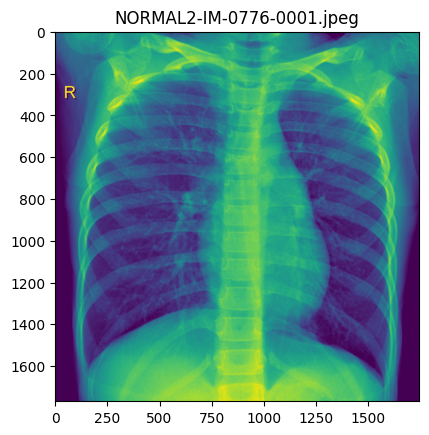

In [72]:
visualize_images(chest_xray_pneumonia_path + '/chest_xray/train/PNEUMONIA', num_images=1)
visualize_images(chest_xray_pneumonia_path + '/chest_xray/train/NORMAL', num_images=1)


#plt.figure(figsize = (5,5))
#plt.imshow(train[-1][0], cmap='gray')
#plt.title(labels[train[-1][1]])

**Preview random selected image from each dataset**

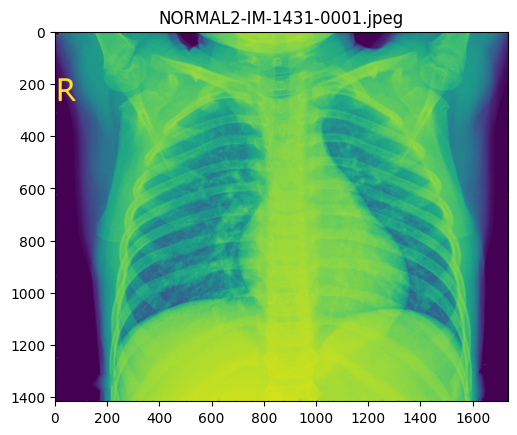

In [73]:
visualize_images(chest_xray_pneumonia_path + '/chest_xray/train/NORMAL', num_images=4)
visualize_images(chest_xray_pneumonia_path + '/chest_xray/test/PNEUMONIA', num_images=4)
visualize_images(chest_xray_pneumonia_path + '/chest_xray/val/NORMAL', num_images=4)

**We perform a grayscale normalization to reduce the effect of illumination's differences.Moreover the CNN converges faster on [0..1] data than on [0..255].**

# Training the Model

In [74]:
# Normalize the data
input_shape = x_train.shape[1:]
num_classes = 2

# Convert the data type of the images to float32
x_train = tf.cast(x_train, tf.float32)  # tf.cast is used to convert the image tensors to float32.
x_test = tf.cast(x_test, tf.float32)

# Normalize the pixel values to a range between 0 and 1
x_train /= 255.0
x_test /= 255.0  #The pixel values of the images are normalized by dividing by 255.0.


y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)
print('x_val shape:', x_val.shape)
print('y_val shape:', y_val.shape)

x_train shape: (5216, 150, 150, 3)
y_train shape: (5216, 2)
x_test shape: (624, 150, 150, 3)
y_test shape: (624, 2)
x_val shape: (16, 150, 150, 3)
y_val shape: (16,)


In [75]:
def lr_schedule(epoch):
    lr = 1e-3
    if epoch > 180:
        lr *= 0.5e-3
    elif epoch > 160:
        lr *= 1e-3
    elif epoch > 120:
        lr *= 1e-2
    elif epoch > 80:
        lr *= 1e-1
    print('Learning rate:', lr)
    return lr

In [76]:
def resnet_layer(inputs,
                 num_filters=16,
                 kernel_size=3,
                 strides=1,
                 activation='relu',
                 batch_normalization=True,
                 conv_first=True):

    conv = Conv2D(num_filters,
                  kernel_size=kernel_size,
                  strides=strides,
                  padding='same',
                  kernel_initializer='he_normal',
                  kernel_regularizer=l2(1e-4))

    x = inputs
    x = CheckeredMaskLayer()(x)
    x = RandomFlip("horizontal_and_vertical", input_shape=(150, 150, 3))(x)
    x = RandomRotation(0.2)(x)
    x = Dropout(0.25)(x)
    if conv_first:
        x = conv(x)
        if batch_normalization:
            x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
    else:
        if batch_normalization:
            x = BatchNormalization()(x)
        if activation is not None:
            x = Activation(activation)(x)
        x = conv(x)
    return x

In [77]:
def resnet_v1(input_shape=input_shape, depth=20, num_classes=2):
    if (depth - 2) % 6 != 0:
        raise ValueError('depth should be 6n + 2')

    num_filters = 16
    num_res_blocks = int((depth - 2) / 6)
    inputs = Input(shape=input_shape)
    x = resnet_layer(inputs=inputs, conv_first=False)

    for stack in range(3):
        for res_block in range(num_res_blocks):
            strides = 1
            if stack > 0 and res_block == 0:
                strides = 2  # Downsample
            y = resnet_layer(x, num_filters=num_filters, strides=strides, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters, activation=None, conv_first=False)
            if stack > 0 and res_block == 0:
                x = resnet_layer(x, num_filters=num_filters, kernel_size=1,
                                 strides=strides, activation=None, batch_normalization=False, conv_first=False)
            x = Add()([x, y])
            x = Activation('relu')(x)
        num_filters *= 2

    x = AveragePooling2D(pool_size=8)(x)
    y = Flatten()(x)
    #outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y) # use sigmoid instead of softmax activation
    model = Model(inputs=inputs, outputs=outputs)
    return model

In [78]:
def resnet_v2(input_shape, depth, num_classes=2):
    if (depth - 2) % 9 != 0:
        raise ValueError('depth should be 9n + 2')

    num_filters_in = 16
    num_res_blocks = int((depth - 2) / 9)
    inputs = Input(shape=input_shape)
    x = resnet_layer(inputs, num_filters=num_filters_in, conv_first=True)

    for stage in range(3):
        for res_block in range(num_res_blocks):
            activation = 'relu'
            batch_normalization = True
            strides = 1
            if stage == 0:
                num_filters_out = num_filters_in * 4
                if res_block == 0:
                    activation = None
                    batch_normalization = False
            else:
                num_filters_out = num_filters_in * 2
                if res_block == 0:
                    strides = 2
            y = resnet_layer(x, num_filters=num_filters_in, kernel_size=1,
                             strides=strides, activation=activation,
                             batch_normalization=batch_normalization, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters_in, conv_first=False)
            y = resnet_layer(y, num_filters=num_filters_out, kernel_size=1, conv_first=False)
            if res_block == 0:
                x = resnet_layer(x, num_filters=num_filters_out, kernel_size=1,
                                 strides=strides, activation=None, batch_normalization=False)
            x = Add()([x, y])
        num_filters_in = num_filters_out

    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = AveragePooling2D(pool_size=8)(x)
    y = Flatten()(x)
    #outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y)
    outputs = Dense(num_classes, activation='softmax', kernel_initializer='he_normal')(y) # use sigmoid instead of softmax activation

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [79]:
import numpy as np
batch_size = 32
#epochs = 64
epochs = 128 # for see if it works
data_augmentation  = False
version = 2 # 1 # the more elaborated model
# define depth here according to version
model_type = 'ResNet %dv%d' % (20, 1)
save_dir = os.path.join(os.getcwd(), 'saved_models')
model_name = 'cifar10_%s_model.{epoch:03d}.keras' % model_type
os.makedirs(save_dir, exist_ok=True)
filepath = os.path.join(save_dir, model_name)
checkpoint = ModelCheckpoint(filepath=filepath,
                             monitor='val_accuracy',
                             verbose=1,
                             save_best_only=True)
lr_scheduler = LearningRateScheduler(lr_schedule)
early_stop = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, mode='max', verbose=1)
lr_reducer = ReduceLROnPlateau(factor=np.sqrt(0.1), cooldown=0, patience=5, min_lr=0.5e-6)
swap_EMA_rates = SwapEMAWeights(swap_on_epoch=True)
callbacks = [checkpoint, lr_reducer, lr_scheduler], # early_stop] #, swap_EMA_rates]
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.3, min_lr=0.000001)

In [80]:
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
if version == 1:
    #model = resnet_v1(input_shape=input_shape, depth=20, num_classes=num_classes)
    model = resnet_v1(input_shape=input_shape, depth=26, num_classes=num_classes)
else:
   # model = resnet_v2(input_shape=input_shape, depth=38, num_classes=num_classes)
    model = resnet_v2(input_shape=input_shape, depth=47, num_classes=num_classes)
model.compile(loss='categorical_crossentropy',
              optimizer=Adam(learning_rate=lr_schedule(0), use_ema=False),
              metrics=['accuracy'])
model.summary()


Learning rate: 0.001


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ checkered_mask_lay… │ (None, 150, 150,  │          0 │ input_layer_2[0]… │
│ (CheckeredMaskLaye… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_101     │ (None, 150, 150,  │          0 │ checkered_mask_l… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_101 │ (None, 150, 150,  │          0 │ random_flip_101[… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_98          │ (None, 150, 150,  │          0 │ random_rotation_… │
│ (Dropout)           │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 150, 150,  │        448 │ dropout_98[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │         64 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_92       │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ checkered_mask_lay… │ (None, 150, 150,  │          0 │ activation_92[0]… │
│ (CheckeredMaskLaye… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_102     │ (None, 150, 150,  │          0 │ checkered_mask_l… │
│ (RandomFlip)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_102 │ (None, 150, 150,  │          0 │ random_flip_102[… │
│ (RandomRotation)    │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_99          │ (None, 150, 150,  │          0 │ random_rotation_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 150, 150,  │        272 │ dropout_99[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ checkered_mask_lay… │ (None, 150, 150,  │          0 │ conv2d_99[0][0]   │
│ (CheckeredMaskLaye… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_103     │ (None, 150, 150,  │          0 │ checkered_mask_l… │
│ (RandomFlip)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_103 │ (None, 150, 150,  │          0 │ random_flip_103[… │
│ (RandomRotation)    │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_100         │ (None, 150, 150,  │          0 │ random_rotation_

 Total params: 1,404,450 (5.36 MB)

 Trainable params: 1,395,778 (5.32 MB)

 Non-trainable params: 8,672 (33.88 KB)

**The data seems imbalanced . To increase the no. of training examples, we will use data augmentation /optional below**


#### **Parameters for augmentation**
**_For the data augmentation, we choose to :_**
1. Randomly rotate some training images by 35 degrees
2. ZCA Whitening Off, Epsilon 1e-09 instead of 1e-06
3. Randomly Zoom by 25% some training images
4. Randomly shift images horizontally by 10% of the width
5. Randomly shift images vertically by 20% of the height
6. Randomly flip images horizontally.
7. Randomly flip images vertically.
8. Samplewise / Featurewise standard normalization is True

...
Once our model is ready, we fit the training dataset.

In [ ]:
if not data_augmentation:
    print('Not using data augmentation.')
    history = model.fit(x_train, y_train,
                        batch_size=batch_size,
                        epochs=epochs,
                        validation_data=(x_test, y_test),
                        shuffle=True,
                        callbacks=callbacks,
                        verbose=1)
else:
    print('Using real-time data augmentation.')
    datagen = ImageDataGenerator(
    rescale=1./150,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest')
    dval_test_datagen = ImageDataGenerator(rescale=1./150)
    datagen.fit(x_train)
    dval_test_datagen.fit(x_test)
    dval_test_datagen.fit(x_val)
    history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
                        steps_per_epoch=x_train.shape[0] // batch_size,
                        epochs=epochs,
                        validation_data=(x_test, y_test),
                        shuffle=True,
                        callbacks=callbacks,
                        verbose=1)

Not using data augmentation.
Learning rate: 0.001
Epoch 1/128
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7376 - loss: 1.4986
Epoch 1: val_accuracy improved from None to 0.63462, saving model to /content/saved_models/cifar10_ResNet 20v1_model.001.keras

Epoch 1: finished saving model to /content/saved_models/cifar10_ResNet 20v1_model.001.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 381ms/step - accuracy: 0.8112 - loss: 1.3099 - val_accuracy: 0.6346 - val_loss: 10.0062 - learning_rate: 0.0010
Learning rate: 0.001
Epoch 2/128
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.8732 - loss: 1.0601
Epoch 2: val_accuracy did not improve from 0.63462
163/163 ━━━━━━━━━━━━━━━━━━━━ 58s 356ms/step - accuracy: 0.8804 - loss: 1.0132 - val_accuracy: 0.6234 - val_loss: 10.1627 - learning_rate: 0.0010
Learning rate: 0.001
Epoch 3/128
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9008 - loss: 0.8676
Epoch 3: val_accuracy did not improve from 0.63462
163/163 ━━━━━━━━━━━━━━━━━━━━

#### **Evaluate Model**

In [ ]:
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

# Analysis after Model Training

In [ ]:
plt.title('Training Accuracy vs Validation Accuracy')

plt.plot(history.history['accuracy'], color='red',label='Train')
plt.plot(history.history['val_accuracy'], color='blue',label='Validation')

plt.legend()

In [ ]:
predictions = model.predict(x_test)
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

In [ ]:
# Plotting the graph of Accuracy and Validation loss
plt.title('Training Loss vs Validation Loss')

plt.plot(history.history['loss'], color='red',label='Train')
plt.plot(history.history['val_loss'], color='blue',label='Validation')

plt.legend()

In [ ]:
pred = model.predict(x_test)

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import image_dataset_from_directory, to_categorical

In [ ]:

labelencoder = LabelEncoder()
#y = to_categorical(labelencoder.fit_transform(x_train))
conf_mat = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(pred, axis=1))
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=2, yticklabels=2, cbar=False)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Now look for CNN

#### The simple model definition

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)

In [ ]:
print('train_ds to tensor')
x_train, y_train = dataset_to_tensors(train_ds)
#dataset_to_tensors is function where we seprate  images and label
print('test_ds to tensor')
x_test, y_test = dataset_to_tensors(test_ds)
print('val_ds to tensor')
x_val, y_val = dataset_to_tensors(val_ds)
print('--- !!Finished tensor conversion !! ---')

In [ ]:
# Training the Model
# Normalize the data
input_shape = x_train.shape[1:]
num_classes = 2

# Convert the data type of the images to float32
x_train = tf.cast(x_train, tf.float32)  # tf.cast is used to convert the image tensors to float32.
x_test = tf.cast(x_test, tf.float32)

# Normalize the pixel values to a range between 0 and 1
x_train /= 255.0
x_test /= 255.0  #The pixel values of the images are normalized by dividing by 255.0.

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
print('x_test shape:', x_test.shape)
print('y_test shape:', y_test.shape)
print('x_val shape:', x_val.shape)
print('y_val shape:', y_val.shape)

In [ ]:

# Config
IMG_SIZE   = (150, 150)
BATCH_SIZE = 32
EPOCHS_CNN = 50
EPOCHS_TL  = 20
LR         = 1e-4

def build_custom_cnn(input_shape=(150, 150, 3)):
    model = Sequential([
        # data augmentation
        CheckeredMaskLayer(),
        #RandomFlip("horizontal_and_vertical"),
        #RandomRotation(0.2),
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Classifier head — GAP avoids param explosion from Flatten
        # Flatten() → 28*28*128 = 100,352 → Dense(256) = 25.6M params!
        # GlobalAveragePooling2D → 128 → Dense(256) = only 33K params
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(2, activation='sigmoid')  # Binary output
    ], name='CustomCNN')
    return model

In [ ]:

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=Adam(learning_rate=LR, use_ema=False),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)
cnn_model.summary()

#### The training of the model

In [ ]:
# --- Callbacks ---
callbacks_cnn = [
    EarlyStopping(monitor='val_auc', patience=7, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
   # SwapEMAWeights(swap_on_epoch=False),
    ModelCheckpoint('best_custom_cnn.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=1)
]
if data_augmentation:
    datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=True,  # divide inputs by std of the dataset
        samplewise_std_normalization=True, # divide each input by its std
        #zca_whitening=True, # apply ZCA whitening
        zca_epsilon=1e-09, # apply ZCA epsilon value
        rotation_range = 35,  # randomly rotate images in the range (degrees, 0 to 180)
        zoom_range = 0.25, # Randomly zoom image
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.2,  # randomly shift images vertically (fraction of total height)
        horizontal_flip = True,  # randomly flip images
        vertical_flip=True)  # randomly flip images
    datagen.fit(x_train)
# --- Train ---
    print('Training Custom CNN with augmentation...')

    cnn_history = cnn_model.fit(datagen.flow(x_train, y_train, batch_size=30),
                        epochs=EPOCHS_CNN,
                        validation_data=(x_test, y_test),
                        callbacks=callbacks_cnn,
                        shuffle=True,
                        verbose=1
                        )
else:
    # --- Train ---
    print('Training Custom CNN w/o augmentation...')
    cnn_history = cnn_model.fit(x_train, y_train,
                        epochs=EPOCHS_CNN,
                        validation_data=(x_test, y_test),
                        callbacks=callbacks_cnn,
                        shuffle=True,
                        verbose=1
                        )


In [ ]:
print("Loss of the model is - " , cnn_model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , cnn_model.evaluate(x_test,y_test)[1]*100 , "%")

In [ ]:
plt.title('Training Accuracy vs Validation Accuracy (CNN)')

plt.plot(cnn_history.history['accuracy'], color='red',label='Train')
plt.plot(cnn_history.history['val_accuracy'], color='blue',label='Validation')

plt.legend()

In [ ]:
predictions = cnn_model.predict(x_test)
predictions = predictions.reshape(1,-1)[0]
predictions[:15]

In [ ]:
# Plotting the graph of Accuracy and Validation loss
plt.title('Training Loss vs Validation Loss (CNN)')

plt.plot(cnn_history.history['loss'], color='red',label='Train')
plt.plot(cnn_history.history['val_loss'], color='blue',label='Validation')

plt.legend()

In [ ]:
pred = cnn_model.predict(x_test)

In [ ]:
labelencoder = LabelEncoder()
#y = to_categorical(labelencoder.fit_transform(x_test))
conf_mat = confusion_matrix(np.argmax(y_test, axis=1), np.argmax(pred, axis=1))
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=2, yticklabels=2, cbar=False)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
history_cnn_wo_aug = cnn_model.fit(
    x_train, y_train,
    epochs=EPOCHS_CNN,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    callbacks=callbacks_cnn,
    shuffle=True,
    verbose=1)

#### Install necessary packages